# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# import libreries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# load datasets
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# show the first 5 rows of plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# show the first 5 rows of users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# show the first 5 rows of usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# count of nulls for users
print(users.isna().sum())
print()
print(users.isna().mean()*100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# count of nulls for usage
print(usage.isna().sum())
print()
print(usage.isna().mean()*100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


For the **users** dataset, two columns with null values are observed: 'city' with 11.72% and 'churn_date' with 88.35%. It is recommended to investigate and impute the 'city' column, while the 'churn_date' column should be removed due to the high percentage of missing values.

For the **usage** dataset, three columns contain null values: 'date' with less than 1%, 'duration' with 55.19%, and 'length' with 44.74%.

The recommendations are:

- For 'date', since the percentage of nulls is less than 5%, this is a simple case. It is recommended to impute these values or leave them as nulls.
- For 'length' and 'duration', investigate whether imputation is possible; otherwise, remove the columns.

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:

 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- The column **user_id** has a total of 4000 thousand rows and a high distribution indicating that each user has their own unique registration number, its function is to identify records.
- The column **age**, a value of -999 is observed, which must be imputed so that it does not affect the analysis.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- The columns `id` and `user_id` exhibit a high distribution, indicating that each user has their own unique registration number.
- The columns `duration` and `length` contain a significant number of missing rows, which could suggest recording errors.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- In the `city` column, we observe a sentinel value (?) and duplicate city names.
- In the `plan` column, there are 2 types "Basic" and "Premium".

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- The `type` column, it is observed that text messages are used more frequently than calls.

---
✍️ **Comment**: We observe a sentinel value (?) in the `city` column and duplicate city names; we recommend imputing and standardizing the city names to avoid distinct segmentations. Also a sentinel value (-999) in the `age` column we recommended to impute with mean or median.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date']= pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['year'] = users['reg_date'].dt.year
users['year'].value_counts(dropna=False)

2024    1330
2023    1316
2022    1314
2026      40
Name: year, dtype: int64

In `reg_date`, there are previous years (2022, 2023) and future dates (2026)

In [19]:
#count of invalid date 2026
users[users['year'] == 2026].shape[0]

40

In [20]:
# Revisar los años presentes en `date` de usage
usage['year']= usage['date'].dt.year
usage['year'].value_counts(dropna=False)

2024.0    39950
NaN          50
Name: year, dtype: int64

In [21]:
#count of invalid date 2026
usage[usage['year'] == 2026].shape[0]

0

In `date` column, all of the dates are from 2024 and also 1% of null values.         

Basaremos el análisis en estas fechas.

✍️ **Comment**: 

- For the `year` column in `users`, we have future year 2026 the recommendation for the analysis is to remove only future dates.
- For the `year` column in `usage`, there are 50 null values, which is less than 1%, so they can be removed without affecting the analysis.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Replace -999 with the median of age
users['age'] = users['age'].replace(-999, np.nan)
age_mediana  = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Review changes
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Replace ? with NA in city
users['city'] = users['city'].replace( '?', pd.NA)

# Review changes
users['city'].unique()

array(['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [24]:
#unificar nulos '<NA>' y 'nan'
users['city'] = users['city'].astype('string')
users['city'].unique()

<StringArray>
['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali']
Length: 7, dtype: string

In [25]:
# Marcar fechas futuras como NA para reg_date
invalid_2026 = users['reg_date'].dt.year == 2026
users.loc[invalid_2026, 'reg_date'] = pd.NaT

# Verificar cambios
invalid_2026.sum()

40

In [26]:
#Confirmation 40  null values
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()*100

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [28]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()*100

type
call    99.932991
text     0.000000
Name: length, dtype: float64

 This is exactly MAR because  the missingness depends on another observed variable `type`; calls have `duration` but no length, and texts have `length` but no duration.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({"is_text":"sum","is_call":"sum","duration":"sum"}).reset_index()\
                                    .rename(columns={"is_text":"messages_qty","is_call":"calls_qty","duration":"total_call_minutes"})# Rename columns

# observar resultado
usage_agg.head(3)

,user_id,messages_qty,calls_qty,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on=["user_id","user_id"], how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,messages_qty,calls_qty,total_call_minutes
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:
#numeric column list and categorical column list
print(user_profile.select_dtypes(include="number").columns.tolist())
print(user_profile.select_dtypes(include="object").columns.tolist())

['user_id', 'age', 'year', 'messages_qty', 'calls_qty', 'total_call_minutes']
['first_name', 'last_name', 'plan', 'churn_date']


In [32]:
# Resumen estadístico de las columnas numéricas
user_profile[["age","messages_qty","calls_qty","total_call_minutes"]].describe()

,age,messages_qty,calls_qty,total_call_minutes
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [33]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)*100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

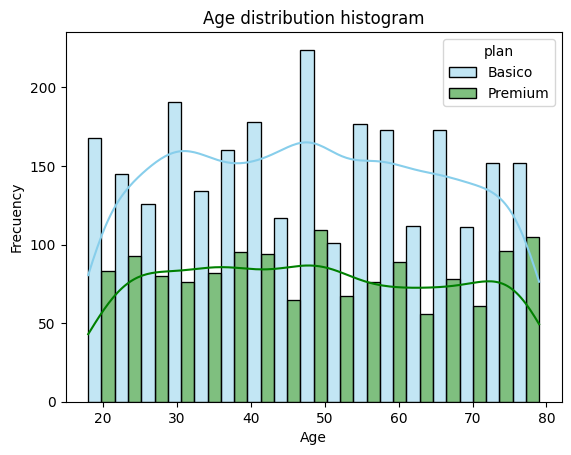

In [34]:
#Histogram to visualize age
sns.histplot(data=user_profile, x="age", hue='plan', bins=17, palette=['skyblue','green'], kde=True, multiple="dodge")
plt.xlabel('Age')
plt.ylabel('Frecuency')
plt.title('Age distribution histogram')
plt.show()

💡Insights:
- Basic Plan: Shows a higher user volume with two key concentration segments: young adults (28–34 years old) and a primary peak among the middle-aged (46–52 years old).

- Premium Plan: Shows lower demand but an even distribution across the user age range (20–75 years old), indicating that the willingness to pay for this plan is not determined by the customer's age.

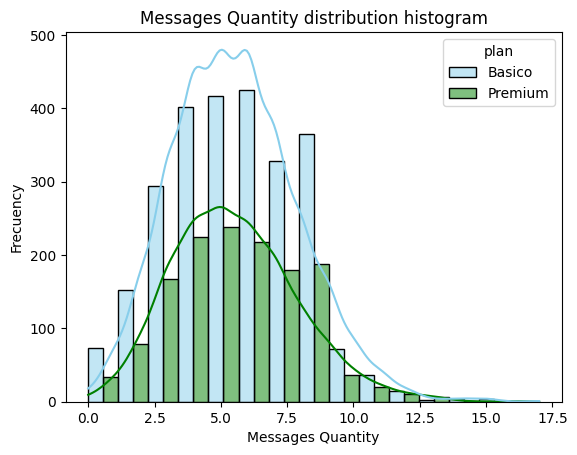

In [35]:
# Histograma para visualizar la messages_qty
sns.histplot(data=user_profile, x="messages_qty", hue='plan', bins=15, palette=['skyblue','green'], kde=True, multiple="dodge")
plt.xlabel('Messages Quantity')
plt.ylabel('Frecuency')
plt.title('Messages Quantity distribution histogram')
plt.show()

💡Insights:
- We observe a right-skewed distribution, with a concentration of users sending between 3 and 8 messages daily. While we see taller bars for the Basic plan, this reflects the larger number of users on that plan, not a higher volume of messages sent.

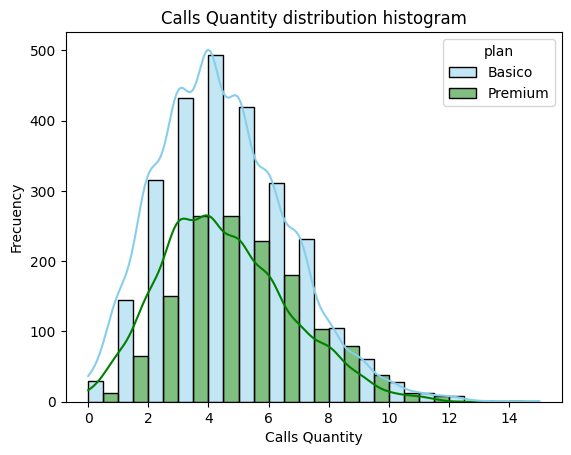

In [36]:
# Histograma para visualizar la calls_qty
sns.histplot(data=user_profile, x="calls_qty", hue='plan', bins=15, palette=['skyblue','green'], kde=True, multiple="dodge")
plt.xlabel('Calls Quantity')
plt.ylabel('Frecuency')
plt.title('Calls Quantity distribution histogram')
plt.show()

💡Insights:
- Right-skewed distribution with a concentration of between 3 and 6 calls.
- Basic Plan: Shows a pronounced peak at 4 calls (frequency close to 500), with a gradual decline starting from 6 calls.
- Premium Plan: For premium users, making 3, 4, or 5 calls is equally likely; there is no single preferred number within that range.

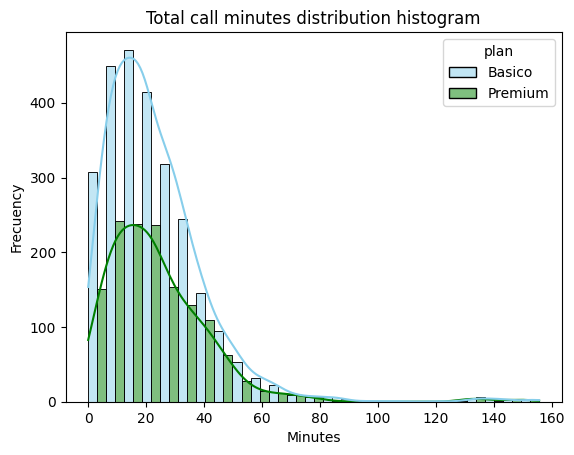

In [37]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="total_call_minutes", hue='plan', bins=25, palette=['skyblue','green'], kde=True, multiple="dodge")
plt.xlabel('Minutes')
plt.ylabel('Frecuency')
plt.title('Total call minutes distribution histogram')
plt.show()

💡Insights:
- Right-skewed distribution with a concentration of call durations between 5 and 30 minutes. A slight uptick is observed at the end of the distribution around 130–140 minutes—representing a segment of users with extreme usage patterns (potentially long-distance calls or conference sessions).

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
 - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

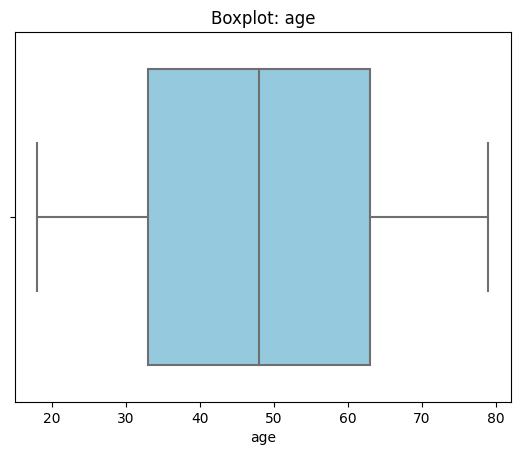

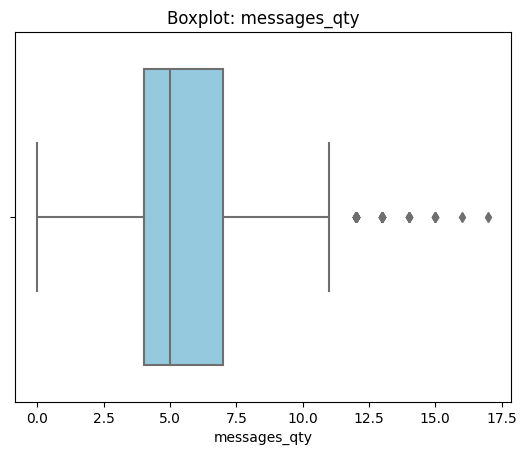

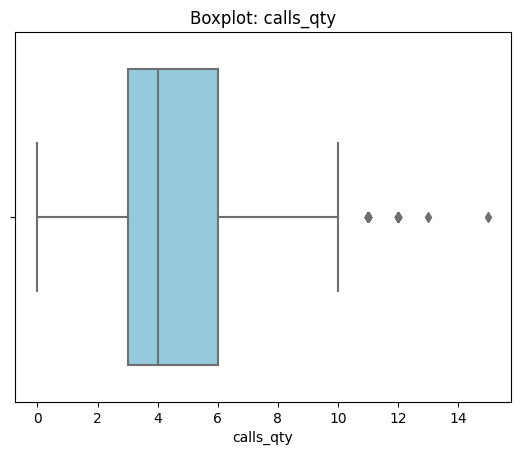

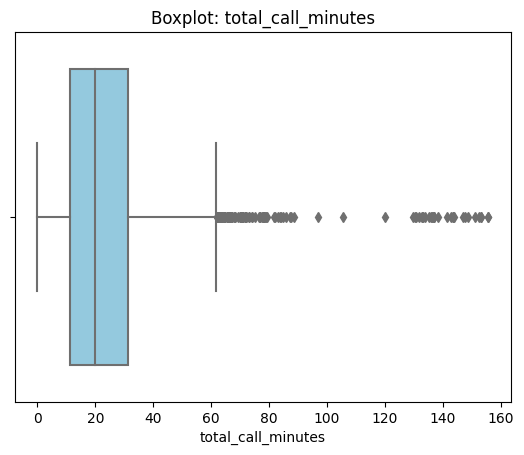

In [38]:
# Visualizando usando BoxPlot 
numeric_columns = ['age', 'messages_qty', 'calls_qty', 'total_call_minutes']			

for col in numeric_columns:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show() 


💡Insights: 
- Age: No presenta ningun valor atípico.Esto indica que los datos demográficos recopilados son consistentes y reflejan un rango continuo y razonable de edades dentro de la base de clientes.
- messages_qty: Se observan 6 valores atípicos distintos entre 12 y 17 mensajes, sugiere un uso ocasional intensivo del servicio por un grupo reducido de segmentos con preferencia a enviar mensajes de texto.
- calls_qty: Se observan 4 valores atípicos distintos entre 11 y 15 llamada, sugiere un uso ocasional intensivo del servicio por un segmento con preferencias a las llamadas.
- total_call_minutes: Se detecta una presencia significativa de valores atípicos en la cola derecha de la distribución (de 60 a 150 minutos). Este patrón sugiere dos hipótesis a evaluar:

    Oportunidad comercial: La existencia de un nicho de usuarios con consumo intensivo de voz que podría ser retenido o monetizado mediante planes especializados de minutos ilimitados.

    Calidad de datos: Posibles anomalías en la medición/registro del tiempo de llamadas.

In [39]:
# Calcular límites con el método IQR
limit_columns = ['messages_qty', 'calls_qty', 'total_call_minutes']

for col in limit_columns:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col)
    print('First quartile: ', Q1)
    print('Third quartile: ', Q3)
    print('IQR: ', IQR)
    print('Lower limit:', lower)
    print('Upper limit:', upper)
    print()

messages_qty
First quartile:  4.0
Third quartile:  7.0
IQR:  3.0
Lower limit: -0.5
Upper limit: 11.5

calls_qty
First quartile:  3.0
Third quartile:  6.0
IQR:  3.0
Lower limit: -1.5
Upper limit: 10.5

total_call_minutes
First quartile:  11.12
Third quartile:  31.415
IQR:  20.295
Lower limit: -19.322500000000005
Upper limit: 61.8575



In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[limit_columns].describe()

,messages_qty,calls_qty,total_call_minutes
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


Data cleaning decision: After analyzing the outliers detected using the IQR method, I have decided to retain them in the dataset. These values ​​do not represent recording errors (they are consistent with service usage) but rather identify a segment of high-usage users. Removing this data would bias the analysis of actual customer behavior.

💡Insights:
- cant_mensajes: retain outliers, as the message count may reflect genuine user activity.
- cant_llamadas: retain outliers, as this may represent actual user behavior.
- cant_minutos_llamada: retain, as it aligns with high call volume and, consequently, the total duration in minutes.
___________________________________________________________________________________________________________________________
Decisión de limpieza: Tras analizar los valores atípicos detectados mediante el método IQR, he decidido conservarlos en el dataset. Estos valores no representan errores de registro (son coherentes con el uso del servicio), sino que identifican a un segmento de usuarios de alto consumo. Eliminar estos datos sesgaría el análisis del comportamiento real de los clientes.

💡Insights: 
- cant_mensajes: mantener outliers dado que la cantidad de mensajes pueden ser datos reales de usuarios.
- cant_llamadas: mantener outliers dado que puede ser comportamientos reales de los usuarios.
- cant_minutos_llamada: mantener dado que coincide con el alto consumo de llamadas y por tanto el total de minutos 


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [41]:
# Crear columna grupo_uso

# Asignar 'Uso medio' a quienes tienen llamadas y mensajes < 10
user_profile.loc[(user_profile['calls_qty'] < 10) & (user_profile['messages_qty'] < 10), 'use_group'] = "Medium use"

# Asignar 'Bajo uso' a quienes tienen llamadas y mensajes < 5 (sobrescribe 'Uso medio' en estos casos)
user_profile.loc[(user_profile['calls_qty'] < 5) & (user_profile['messages_qty'] < 5), 'use_group'] = "Low use"

# Asignar 'Alto uso' a quienes no tienen asignado 'use_group' (es decir, el resto)
user_profile.loc[user_profile['use_group'].isna(), 'use_group'] = "High use"

In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,messages_qty,calls_qty,total_call_minutes,use_group
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7,3,23.70,Medium use
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5,10,33.18,High use
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5,2,10.74,Medium use
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11,3,8.99,High use
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4,3,8.01,Low use


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [43]:
# Crear columna grupo_edad
user_profile.loc[user_profile['age'] < 60, 'age_group']         = 'Adult'
user_profile.loc[user_profile['age'] < 30, 'age_group']         = 'Young'
user_profile.loc[user_profile['age_group'].isna(), 'age_group'] = 'Older Adult'

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,year,messages_qty,calls_qty,total_call_minutes,use_group,age_group
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7,3,23.70,Medium use,Adult
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5,10,33.18,High use,Adult
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5,2,10.74,Medium use,Adult
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11,3,8.99,High use,Older Adult
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4,3,8.01,Low use,Older Adult


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

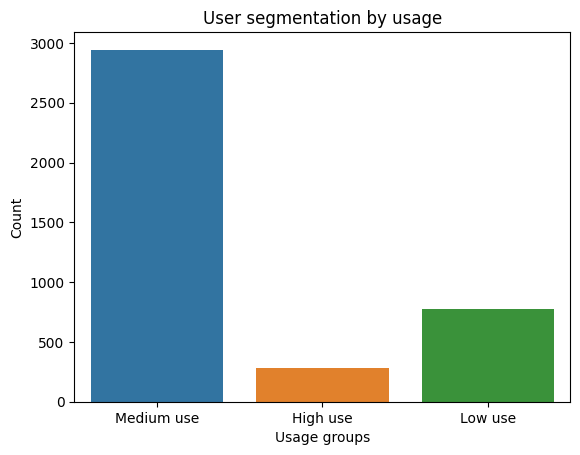

In [45]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='use_group')
plt.title("User segmentation by usage")
plt.xlabel("Usage groups")
plt.ylabel('Count')
plt.show()

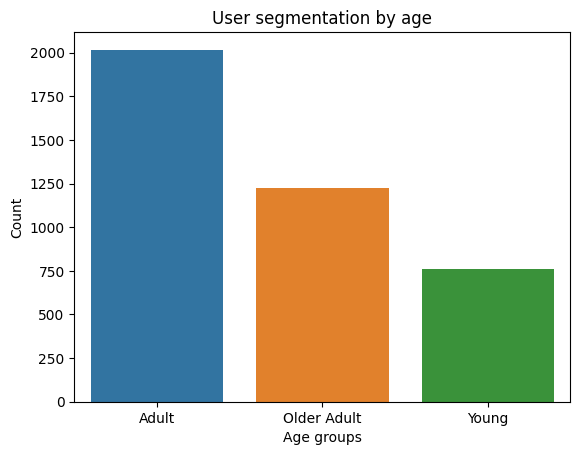

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='age_group')
plt.title("User segmentation by age")
plt.xlabel("Age groups")
plt.ylabel('Count')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Two columns contained null values: 'city' (11.72%) and 'churn_date' (88.35%).

- Placeholder values (such as '?') in the 'city' column were formally converted to nulls.

- Invalid values in the 'age' column (-999) were imputed using the median.

Usage dataset:

- Three columns contained null values: 'date' (< 1%), 'duration' (55.19%), and 'length' (44.74%).
- For the 'date' column, records with future dates (year 2026) were removed

🔍 **Segmentos por Edad**

- Adults (26–30 years old) represent the group with the highest phone plan usage, followed by older adults (46–52 years old) with moderate usage. Young people constitute the segment with the lowest consumption.

- Basic phone plans are primarily used by adults and older adults, which correlates directly with high call volumes.

  
📊 **Segmentos por Nivel de Uso**

- The majority of customers maintain average or moderate phone plan usage.

- A distinct segment of 350 to 450 users with intensive service usage was identified.


💡 **Recomendaciones**

- Loyalty for the core segment: Design retention strategies focused on average-usage users, as they constitute the largest customer base.

- Monetizing the high-usage niche: Create an exclusive plan with unlimited minutes and premium benefits to capture greater value from the high-consumption segment.

- Optimizing offers by age: Tailor the marketing of basic plans to highlight voice services when targeting adults and older adults.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`